In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt;


In [11]:
df= pd.read_csv('loan_data.csv')

In [12]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [14]:
df.isnull()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,False,False,False,False,False,False,False,False,False,False,False,False,False,False
44996,False,False,False,False,False,False,False,False,False,False,False,False,False,False
44997,False,False,False,False,False,False,False,False,False,False,False,False,False,False
44998,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [15]:
df.sum()

person_age                                                                1249388.0
person_gender                     femalefemalefemalefemalemalefemalefemalefemale...
person_education                  MasterHigh SchoolHigh SchoolBachelorMasterHigh...
person_income                                                          3614357395.0
person_emp_exp                                                               243465
person_home_ownership             RENTOWNMORTGAGERENTRENTOWNRENTRENTRENTOWNRENTO...
loan_amnt                                                               431242090.0
loan_intent                       PERSONALEDUCATIONMEDICALMEDICALMEDICALVENTUREE...
loan_int_rate                                                             495297.26
loan_percent_income                                                         6287.62
cb_person_cred_hist_length                                                 264037.0
credit_score                                                               2

In [17]:
print(df.isnull().sum())

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64


In [18]:
from sklearn.model_selection import train_test_split

C:\Users\madha\AppData\Local\Temp\ipykernel_15480\1895110890.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='loan_status', data=df, palette='viridis')


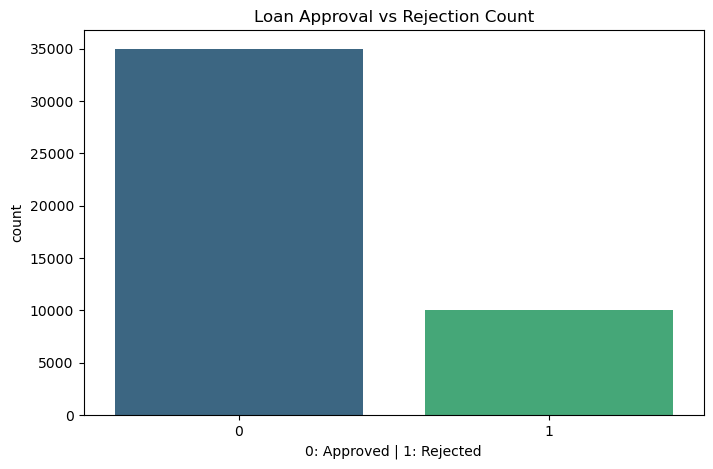

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(x='loan_status', data=df, palette='viridis')
plt.title('Loan Approval vs Rejection Count')
plt.xlabel('0: Approved | 1: Rejected')
plt.show()

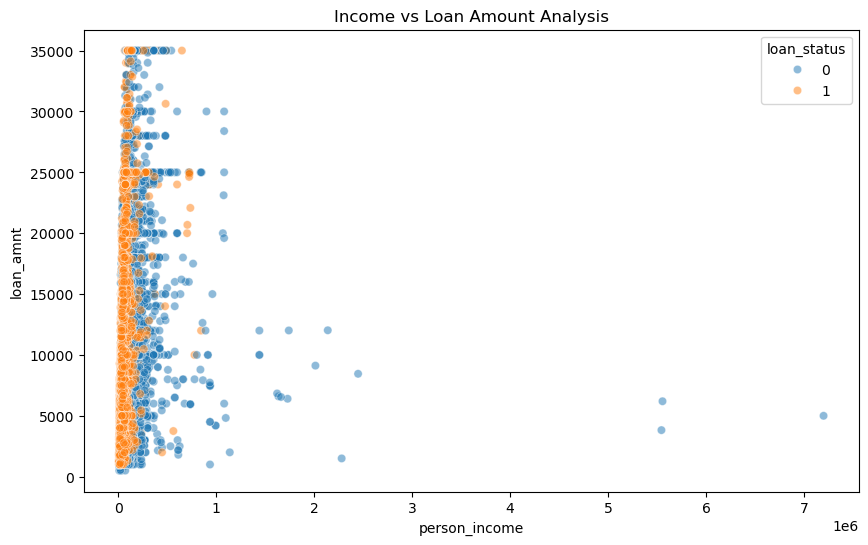

In [21]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='person_income', y='loan_amnt', hue='loan_status', data=df, alpha=0.5)
plt.title('Income vs Loan Amount Analysis')
plt.show()

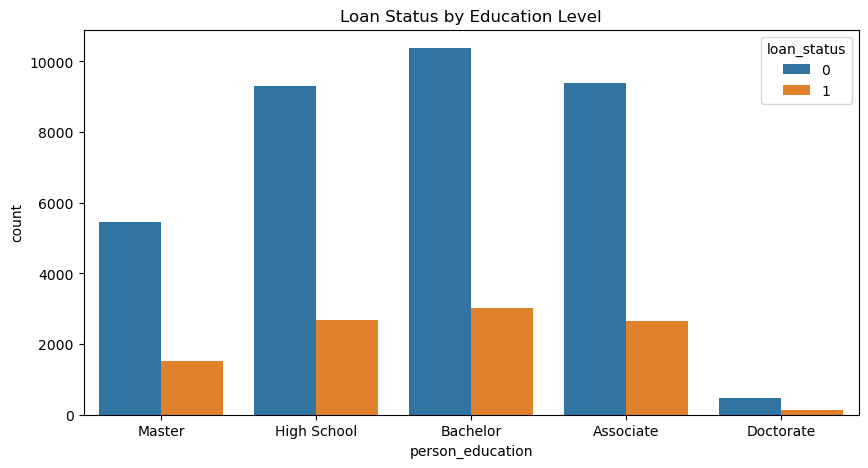

In [22]:
plt.figure(figsize=(10,5))
sns.countplot(x='person_education', hue='loan_status', data=df)
plt.title('Loan Status by Education Level')
plt.show()

In [23]:
from sklearn.model_selection import train_test_split

# X ante 'loan_status' thappa migilina anni columns
X = df.drop('loan_status', axis=1)
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Data Size:", X_train.shape)
print("Testing Data Size:", X_test.shape)

Training Data Size: (36000, 13)
Testing Data Size: (9000, 13)


In [25]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Anni text columns ni list chesi numbers ga marchali
text_columns = ['person_gender', 'person_education', 'person_home_ownership', 
                'loan_intent', 'previous_loan_defaults_on_file']

for col in text_columns:
    df[col] = le.fit_transform(df[col])

# Ippudu data check chesthe anni numbers lo untayi
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,0,4,71948.0,0,3,35000.0,4,16.02,0.49,3.0,561,0,1
1,21.0,0,3,12282.0,0,2,1000.0,1,11.14,0.08,2.0,504,1,0
2,25.0,0,3,12438.0,3,0,5500.0,3,12.87,0.44,3.0,635,0,1
3,23.0,0,1,79753.0,0,3,35000.0,3,15.23,0.44,2.0,675,0,1
4,24.0,1,4,66135.0,1,3,35000.0,3,14.27,0.53,4.0,586,0,1


In [27]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
from sklearn.ensemble import RandomForestClassifier

# Model ni create chesi train cheyandi
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Test data tho predictions cheyandi
y_pred = model.predict(X_test)

In [30]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
print(f"Project Accuracy: {accuracy * 100:.2f}%")
print("\nDetailed Report:\n", classification_report(y_test, y_pred))

Project Accuracy: 92.87%

Detailed Report:
               precision    recall  f1-score   support

           0       0.94      0.97      0.95      6990
           1       0.89      0.78      0.83      2010

    accuracy                           0.93      9000
   macro avg       0.91      0.87      0.89      9000
weighted avg       0.93      0.93      0.93      9000

